## Проектное домашнее задание

> Дедлайн: **30 апреля**

### Разработка поисковой системы для небольшого веб-графа

**Цель:** реализовать поисковую систему, которая индексирует коллекцию веб-страниц и ранжирует результаты, комбинируя BM25 (или TF-IDF) и PageRank.

---

**Формат сдачи:** Jupyter Notebook с:
- Кодом всех реализованных классов и функций
- Ячейками с экспериментами и выводом результатов
- Текстовыми ячейками с анализом и ответами на вопросы
- Визуализациями графа

### Часть 1. Подготовка данных (2 балла)

Создайте коллекцию из **8-10 веб-страниц** на любую тему (например, о здоровье, программировании, спорте). Каждая страница должна содержать:

- `id` (уникальный идентификатор)
- `title` (заголовок)
- `content` (текст страницы, 50-200 слов)
- `outgoing_links` (список id страниц, на которые есть ссылки)

Также укажите для каждой страницы **реальные URL-подобные идентификаторы** (например, `"mayoclinic.org/aspirin"`, `"nih.gov/ibuprofen"`), чтобы можно было определять авторитетность домена для PageRank.

*Пример:*

```python
pages = [
    {
        "id": "page1",
        "url": "mayoclinic.org/aspirin",
        "title": "Aspirin Side Effects",
        "content": "Aspirin can cause stomach bleeding...",
        "outgoing_links": ["page2", "page3"]
    },
    # ... остальные страницы
]
```


In [21]:
import numpy as np
import pandas as pd
import networkx as nx
from math import log, log2
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Создадим коллекцию из 10 веб-страниц с информацией о НИУ ВШЭ для иностранных студентов (общая информация, международные рейтинги, общежития, стипендии). Источник: выдача Google по поисковым запросам `"hse university ranking"`, `"hse dormitories review"`, `"hse scholarships"`. Также добавим пример SEO-оптимизированной страницы (page5) для последующей демонстрации работы PageRank.

In [38]:
pages = [
    {
        "id": "page1",
        "url": "www.hse.ru/en/",
        "title": "HSE University (hse.ru)",
        "content": "HSE University Divisions Faculty & Staff International Partnerships Academic Jobs Alumni University Life Campus in Moscow EN Admissions Programmes & Courses Research International Support About Search News Events HSE University 360° Student Voices Contacts About Key Figures & Facts Sustainability at HSE University Faculties & Departments International Partnerships Faculty & Staff HSE Buildings HSE University for Persons with Disabilities Public Enquiries Studies Admissions Programme Catalogue Undergraduate Graduate Exchange Programmes Summer Schools Semester in Moscow Business Internship Research International Laboratories Research Centres Research Projects Monitoring Studies Conferences & Seminars Academic Jobs Yasin (April) International Academic Conference on Economic and Social Development Media & Resources Publications by staff HSE Journals Publishing House Library HSE Repository of Socio-Economic Information",
        "outgoing_links": ["page3", "page6", "page10"]
    },
    {
        "id": "page2",
        "url": "www.topuniversities.com/universities/hse-university",
        "title": "HSE University: Rankings, Fees & Courses Details (topuniversities.com)",
        "content": "HSE University Location HSE-Moscow, Moscow Russia+3 campus QS World University Rankings 42 Undergrad & Postgrad Programmes 11 % International students Overview Programmes University Information Cost of Living Tuition Fees Scholarships Rankings & Ratings Campus Locations Similar Universities FAQs About HSE University National Research University Higher School of Economics (HSE University) is a major research and academic institution, which regularly appears in high-profile global rankings such as QS, THE and ARWU. Our institution’s innovative approach and well-developed system of international cooperation have helped us to become the only Russian university to appear in the Top-100 of the best young universities, according to THE Young University Rankings, as well as the best university in Russia, according to Forbes Russia.",
        "outgoing_links": ["page1", "page3", "page4"]
    },
    {
        "id": "page3",
        "url": "datadesign.hse.ru/en/ranking",
        "title": "HSE University in world rankings (datadesign.hse.ru)",
        "content": "HSE University in world rankings National rankings Lyceum in rankings The indicators for 2026 are calculated using data from the QS Subject Rankings 2026, THE Subject Rankings, and ARWU Subject Rankings 2025 Positions in QS, THE, ARWU subject/faculty rankingsPositions in QS subject/faculty rankings (4 faculty positions)Positions in THE subject rankingsPositions in ARWU subject rankingsPositions in the Top100 in QS, THE, ARWU subject/faculty rankingsPositions in the Top300 in QS, THE, ARWU subject/faculty rankingsRanks first among all Russian academic institutions or the only Russian institution to be represented in QS, THE, ARWU subject rankingsThe only Russian institution to be represented in QS, THE, ARWU subject rankings",
        "outgoing_links": ["page1"]
    },
    {
        "id": "page4",
        "url": "www.mastersportal.com/rankings-reviews/1448/hse-university.html",
        "title": "HSE University: Rankings & Reviews (mastersportal.com)",
        "content": "University Rankings and Student Reviews HSE University HSE University is ranked 440 in QS World University Rankings by TopUniversities and has an overall score of 4.4 stars, according to student reviews on Studyportals, the best place to find out how students rate their study and living experience at universities from all over the world. On this page you can see how the university is ranked on international rankings and find out what students are saying about their study experience. View all 37 Masters from this university Find out more about this university University World Rankings QS World University Rankings by TopUniversities 440 2026 410 2025 399 2024 World University Rankings by Times Higher Education 501 2026 401 2025 401 2024 Best Global Universities Rankings by U.S. News & World Report 608 2026 584 2025 561 2024 Academic Ranking of World Universities by Shanghai Jiao Tong University 801 2025 701 2024 701 2023 Student Reviews",
        "outgoing_links": ["page1", "page3"]
    },
    {
        "id": "page5",
        "url": "seoblog.com/hse-dormitories",
        "title": "HSE dormitories (SEO optimized)",
        "content": "Higher School of Economics HSE University the National Research University Moscow Saint Petersburg Russia education students dormitories dorms review good great comfort dormitories rooms comfortable housing optimal convenient international students best option hse dormitory cheap affordable best price discount Russia Moscow student housing review 2024 2025 2026 top rated best dormitories HSE",
        "outgoing_links": ["page1", "page9"]
    },
    {
        "id": "page6",
        "url": "spb.hse.ru/admissions/scholarship",
        "title": "Scholarships and Tuition Fee Waivers - Admissions (spb.hse.ru)",
        "content": "Scholarships and Tuition Fee Waivers Russian Government Scholarship Provides: Free tuition for the whole period of studying; Monthly scholarship ~ 2,100 RUB. Eligibility: Top scores upon passing entrance exams: tests (undergraduate programmes) / portfolio competion and interview (graduate programmes). Please note: the number of Russian Government Scholarships allocated for each educational programme is very limited, and scholarships are highly competitive. Tuition Fee Waivers In order to get tuition fee waivers (%) applicants have to get high results upon entrance exams: total scores for 2 exams (undergraduate programmes) / portfolio and interview (graduate programmes). The tuition fee waiver is awarded automatically upon completion of entrance trials. Eligibility for Undergraduate Applicants: 140-149 points – 25%; 150-169 points – 50%; Above 170 points – 70%*. * Under the condition of getting the minimum scores for each of 2 exams. Eligibility for Graduate Applicants: 50-59 points – 25%; 60 and above points – 50%. Regulations on Tuition Fee Discounts for Foreign Citizens in 2025 (Available in Russian)",
        "outgoing_links": ["page1", "page7", "page10"]
    },
    {
        "id": "page7",
        "url": "www.internationalscholarships.com/scholarships/2829/Scholarships_for_Masters_Programs_at_HSE_University_in_Russia",
        "title": "Scholarships for Masters Programs at HSE University in Russia (internationalscholarships.com)",
        "content": "Russian Government Description Applications are currently being accepted for full-tuition scholarships to study at National Research University – Higher School of Economics in Moscow and St. Petersburg. All international students seeking English- or Russian-language graduate education are encouraged to apply. HSE University is one of the top universities in Russia and one of the leaders in Eastern Europe and Eurasia in economics and social sciences. Our students come from all over the world to study in English or Russian in Bachelor’s, Master’s, and non-degree programmes. Fields of study: Computer Science, Economics, Humanities, International Affairs, Management, Mathematics, Social Sciences How to apply: To apply for a scholarship, please fill out the standard HSE online application form (available here) and indicate that you wish to be considered for a scholarship. In your application, you may apply to two programs. Scholarship details: Scholarships cover the full cost of tuition for Master’s programs over the course of two years. Subsidized accommodation at HSE dormitories is available for around 1400 rubles per month. Other Criteria Eligibility:You must already holda Bachelor’s degree or earn one before the program start date (September 2017).",
        "outgoing_links": ["page6", "page10"]
    },
    {
        "id": "page8",
        "url": "www.reddit.com/r/Moscow/comments/gnn1cr/hse_moscow_dorms/",
        "title": "HSE Moscow Dorms: r/Moscow (reddit.com)",
        "content": "Hello everyone. I’ve applied to HSE Moscow and I’ve got accepted in Marketing: Digital Technology and Communications, so basically it’s in the business school. The thing is that the dorms are cheap and people are telling me to try the dorms especially that I don’t know anything about Russia and never been there, and I have never tried dorms in my life. My questions are: do you recommend to try the dorms? And if yes, anyone knows how is it like and how are the rooms there ? Is it a shared bathroom or a private bathroom? Are the bathrooms, and rooms clean ? Is there anything bad about living in dorm? Thanks :)",
        "outgoing_links": ["page9"]
    },
    {
        "id": "page9",
        "url": "spb.hse.ru/soc/illuminated/news/1064486336.html",
        "title": "Why HSE Dorm is Best for Foreign Students (spb.hse.ru)",
        "content": "HSE dorm offers foreign students comfort, privacy and community. Best mix of price, location, social life. Why HSE Dorm is Best for Foreign Students Photo by Nguyen Dang Hoang Nhu from Unsplash Moving to another country for studies is always a significant and sometimes challenging step in life. Especially if it’s Moscow — a huge metropolis with a fast-paced lifestyle and countless opportunities. One of the most important issues for international students coming to study at HSE is choosing housing. There are many options: renting an apartment, leasing a room, staying in hotels or dormitories. In this article, I will explain why the HSE dormitory is the optimal and most convenient option, especially for foreigners. I will examine all the pros and cons in detail and share a real student review. Pros of Living in an HSE Dormitory for International Students",
        "outgoing_links": ["page1", "page8"]
    },
    {
        "id": "page10",
        "url": "spb.hse.ru/io/studyabroad/scholarship",
        "title": "Scholarships - Study Abroad Opportunities for HSE Saint Petersburg Students (spb.hse.ru)",
        "content": "Scholarships Erasmus+ scholarships available for HSE University - Saint Petersburg students in Fall semester 2025-2026 There are no Erasmus+ scholarships for this semester. Third-party scholarships (students have to apply for them independently) More information on financial support for your study abroad experience is available on our page Financial aid and alternative options for studying abroad for HSE students. Tuition fee reassessment for fee-paying students According to the item.3.5.3 of Regulation of the HSE outgoing mobility programmes (in Russian), which was put in action on June 17, 2021, “In case of paying the tuition fee at the foreign host university independently, a student could apply for recalculation of the cost of the tuition fee at NRU HSE with the reduction of the cost of the disciplines passed in the host university after returning from the mobility program. This means that a fee-paying student may apply for the tuition fee reassessment upon successful completion of the study abroad experience at a non-partner university and transferring the planned disciplines to HSE - Saint Petersburg.",
        "outgoing_links": ["page1", "page6", "page7"]
    },
]

print(f"Web-pages collection (total: {len(pages)})")
for i, page in enumerate(pages):
    print(f"\n  {i+1}. {page['title']} // {page['url']}")
    print(f"     Content ({len(page['content'].split())} words): {page['content'][:100]}...")

Web-pages collection (total: 10)

  1. HSE University (hse.ru) // www.hse.ru/en/
     Content (116 words): HSE University Divisions Faculty & Staff International Partnerships Academic Jobs Alumni University ...

  2. HSE University: Rankings, Fees & Courses Details (topuniversities.com) // www.topuniversities.com/universities/hse-university
     Content (117 words): HSE University Location HSE-Moscow, Moscow Russia+3 campus QS World University Rankings 42 Undergrad...

  3. HSE University in world rankings (datadesign.hse.ru) // datadesign.hse.ru/en/ranking
     Content (104 words): HSE University in world rankings National rankings Lyceum in rankings The indicators for 2026 are ca...

  4. HSE University: Rankings & Reviews (mastersportal.com) // www.mastersportal.com/rankings-reviews/1448/hse-university.html
     Content (154 words): University Rankings and Student Reviews HSE University HSE University is ranked 440 in QS World Univ...

  5. HSE dormitories (SEO optimized) // seoblog

### Часть 2. Индексация и поиск (3 балла)

Реализуйте класс `SearchEngine` с методами:

1. `add_page(page)` — добавление страницы в индекс
2. `build_inverted_index()` — построение обратного индекса (слово → список документов с tf)
3. `compute_tfidf_vectors()` — вычисление TF-IDF векторов для всех страниц
4. `compute_pagerank(damping=0.85)` — вычисление PageRank на основе `outgoing_links`
5. `search(query, weights=None, top_k=5)` — поиск с комбинированным ранжированием:
   - `weights['bm25']` — вес BM25
   - `weights['tfidf']` — вес косинусного сходства TF-IDF
   - `weights['pagerank']` — вес PageRank


In [33]:
class SearchEngine:
    '''Класс для поиска веб-страниц по запросу
        на основе алгоритмов PageRank, BM25 и TF-IDF'''
    def __init__(self):
        self.pages = {}
        self.inverted_index = defaultdict(list)
        self.tfidf_matrix = None
        self.tfidf_vectorizer = None
        self.page_vectors = {}
        self.pagerank = {}
        self.doc_freq = defaultdict(int)
        self.total_docs = 0

    def add_page(self, page):
        '''Добавляет в индекс веб-страницу (словарь с атрибутами url, title, content, outgoing_links)'''
        self.pages[page['id']] = {
            'url': page['url'],
            'title': page['title'],
            'content': page['content'],
            'outgoing_links': page['outgoing_links']
        }

    def build_inverted_index(self):
        '''Строит обратный индекс, возвращает список документов с TF'''
        self.inverted_index.clear()
        self.doc_freq.clear()
        self.total_docs = len(self.pages)

        for doc_id, page in self.pages.items():
            words = page['content'].lower().split()
            word_counts = Counter(words)
            unique_words = set(words)

            for word in unique_words:
                self.inverted_index[word].append({
                    'doc_id': doc_id,
                    'tf': word_counts[word]
                })
                self.doc_freq[word] += 1

    def compute_tfidf_vectors(self):
        '''Вычисляет векторы TF-IDF для страниц на английском языке'''
        documents = [self.pages[doc_id]['content'] for doc_id in self.pages.keys()]
        self.tfidf_vectorizer = TfidfVectorizer(stop_words='english')
        self.tfidf_matrix = self.tfidf_vectorizer.fit_transform(documents)

        doc_ids = list(self.pages.keys())
        for i, doc_id in enumerate(doc_ids):
            self.page_vectors[doc_id] = self.tfidf_matrix[i].toarray().flatten()

    def compute_pagerank(self, damping=0.85, max_iter=100, tol=1e-6):
        '''Вычисляет PageRank на основе outgoint_links'''
        n = len(self.pages)
        pages = list(self.pages.keys())
        page_to_idx = {page: i for i, page in enumerate(pages)}

        M = np.zeros((n, n))
        for i, page in enumerate(pages):
            out_links = self.pages[page]['outgoing_links']
            if out_links:
                prob = 1.0 / len(out_links)
                for target in out_links:
                    if target in page_to_idx:
                        j = page_to_idx[target]
                        M[j, i] += prob

        pr = np.ones(n) / n

        for _ in range(max_iter):
            new_pr = (1 - damping) / n + damping * M @ pr
            if np.linalg.norm(new_pr - pr, 1) < tol:
                break
            pr = new_pr

        pr = pr / pr.sum()
        self.pagerank = {page: pr[i] for i, page in enumerate(pages)}

    def compute_bm25_score(self, query, doc_id, k1=1.5, b=0.75):
        '''Вычисляет BM25 score на основе TF'''
        doc = self.pages[doc_id]
        doc_len = len(doc['content'].split())
        avg_doc_len = sum(len(self.pages[d_id]['content'].split()) for d_id in self.pages) / len(self.pages)

        query_words = query.lower().split()
        score = 0

        for word in query_words:
            if word not in self.inverted_index:
                continue

            tf = 0
            for entry in self.inverted_index[word]:
                if entry['doc_id'] == doc_id:
                    tf = entry['tf']
                    break

            if tf == 0:
                continue

            idf = log((self.total_docs - self.doc_freq[word] + 0.5) / (self.doc_freq[word] + 0.5) + 1)

            numerator = tf * (k1 + 1)
            denominator = tf + k1 * (1 - b + b * doc_len / avg_doc_len)
            score += idf * numerator / denominator

        return score

    def compute_tfidf_cosine(self, query):
        '''Вычисляет косинусное сходство между TF-IDF векторами запроса и страницы'''
        query_vec = self.tfidf_vectorizer.transform([query])
        scores = {}
        for doc_id, doc_vec in self.page_vectors.items():
            doc_vec_reshaped = doc_vec.reshape(1, -1)
            similarity = cosine_similarity(query_vec, doc_vec_reshaped)[0][0]
            scores[doc_id] = similarity
        return scores

    def search(self, query, weights=None, top_k=5):
        '''Осуществляет поиск по запросу с заданными весами (комбинированное ранжирование),
            возвращает top_k релевантных страниц со scores'''
        if weights is None:
            weights = {'bm25': 0.34, 'tfidf': 0.33, 'pagerank': 0.33}

        if not self.pagerank:
            self.compute_pagerank()

        tfidf_scores = self.compute_tfidf_cosine(query)

        final_scores = {}
        for doc_id in self.pages.keys():
            bm25_score = self.compute_bm25_score(query, doc_id)
            tfidf_score = tfidf_scores[doc_id]
            pr_score = self.pagerank[doc_id]

            total = (weights.get('bm25', 0) * bm25_score +
                    weights.get('tfidf', 0) * tfidf_score +
                    weights.get('pagerank', 0) * pr_score)
            final_scores[doc_id] = total

        sorted_results = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

        results = []
        for doc_id, score in sorted_results:
            results.append({
                'id': doc_id,
                'title': self.pages[doc_id]['title'],
                'url': self.pages[doc_id]['url'],
                'score': score,
                'pagerank': self.pagerank[doc_id],
                'bm25': self.compute_bm25_score(query, doc_id),
                'tfidf': tfidf_scores[doc_id]
            })

        return results

### Часть 3. Эксперименты (3 балла)

Для **3 разных поисковых запросов** (релевантных вашей коллекции):

1. Выполните поиск с тремя разными конфигурациями весов:
   - Конфиг A: только PageRank
   - Конфиг B: только TF-IDF (или BM25)
   - Конфиг C: гибрид (например, 0.4×TF-IDF + 0.4×BM25 + 0.2×PageRank)

2. Для каждой конфигурации выведите топ-5 результатов с их scores

3. Проанализируйте различия:
   - Какой конфиг лучше находит релевантные страницы?
   - Какой конфиг лучше поднимает авторитетные источники?
   - Приведите пример, когда PageRank "спасает" результат от нерелевантного, но SEO-оптимизированного документа

In [39]:
# создаем объект класса
engine = SearchEngine()
# добавляем страницы
for page in pages:
    engine.add_page(page)

engine.build_inverted_index() # строим обратный индекс
engine.compute_tfidf_vectors() # вычисляем векторы TF-IDF
engine.compute_pagerank(damping=0.85) # вычисляем PageRank

# релевантные запросы
queries = [
    "hse university rankings",
    "hse dormitories reviews",
    "hse scholarships"
]

# конфигурации согласно заданию
configs = {
    "Config A (PageRank only)": {"bm25": 0, "tfidf": 0, "pagerank": 1},
    "Config B (TF-IDF only)": {"bm25": 0, "tfidf": 1, "pagerank": 0},
    "Config C (Hybrid)": {"bm25": 0.4, "tfidf": 0.4, "pagerank": 0.2}
}

# вычисляем результаты, выводим релевантные страницы по каждому конфигу и их скоры
for query in queries:
    print("\n******")
    print(f"Query: '{query}'")

    for config_name, weights in configs.items():
        results = engine.search(query, weights=weights, top_k=5)
        print(f"\n{config_name}:")
        for i, r in enumerate(results, 1):
            print(f"  {i}. {r['title']} | score={r['score']:.4f}")
            print(f"     PR={r['pagerank']:.4f}, BM25={r['bm25']:.4f}, TFIDF={r['tfidf']:.4f}")


******
Query: 'hse university rankings'

Config A (PageRank only):
  1. HSE University (hse.ru) | score=0.2496
     PR=0.2496, BM25=1.0588, TFIDF=0.2209
  2. Scholarships and Tuition Fee Waivers - Admissions (spb.hse.ru) | score=0.1936
     PR=0.1936, BM25=0.0000, TFIDF=0.0000
  3. Scholarships - Study Abroad Opportunities for HSE Saint Petersburg Students (spb.hse.ru) | score=0.1936
     PR=0.1936, BM25=0.9245, TFIDF=0.1461
  4. Scholarships for Masters Programs at HSE University in Russia (internationalscholarships.com) | score=0.1247
     PR=0.1247, BM25=0.7048, TFIDF=0.0896
  5. HSE University in world rankings (datadesign.hse.ru) | score=0.0982
     PR=0.0982, BM25=3.0105, TFIDF=0.2922

Config B (TF-IDF only):
  1. HSE University: Rankings, Fees & Courses Details (topuniversities.com) | score=0.5441
     PR=0.0150, BM25=2.9981, TFIDF=0.5441
  2. HSE University: Rankings & Reviews (mastersportal.com) | score=0.5274
     PR=0.0192, BM25=3.3349, TFIDF=0.5274
  3. HSE University in w

> - Какой конфиг лучше находит релевантные страницы?

Конфиг B (только TF-IDF) лучше находит релевантные страницы именно по содержанию. По всем запросам на 1-3 строки в выдаче попадают почти исключительно релевантные страницы. Однако по запросу 'hse dormitories reviews' наиболее релевантной согласно cosine TF-IDF оказывается SEO-оптимизированная страница, что является явным недостатком подхода.

> - Какой конфиг лучше поднимает авторитетные источники?

Конфиг А (только PageRank) выдает наиболее авторитетные источники (на которые ведет больше всего внешних ссылок) по всем запросам, но часто эти страницы не являются релевантными.

> - Приведите пример, когда PageRank "спасает" результат от нерелевантного, но SEO-оптимизированного документа

В выдаче по запросу 'hse dormitories reviews' SEO-оптимизированный документ занимает первое место при конфиге B, в то время как гибридный конфиг с PageRank опускает его на второе место как наименее авторитетный. То есть, наличие PageRank не "спасает" от появления такого документа в выдаче, но хотя бы снижает его score.

### Часть 4. Визуализация (2 балла)

1. Постройте **граф ссылок** вашей коллекции страниц (направленный граф) с помощью `networkx`
2. Визуализируйте граф: размер узла пропорционален PageRank страницы
3. Подпишите узлы их id или заголовками
4. Сделайте вывод: какие страницы стали "центрами" графа и почему

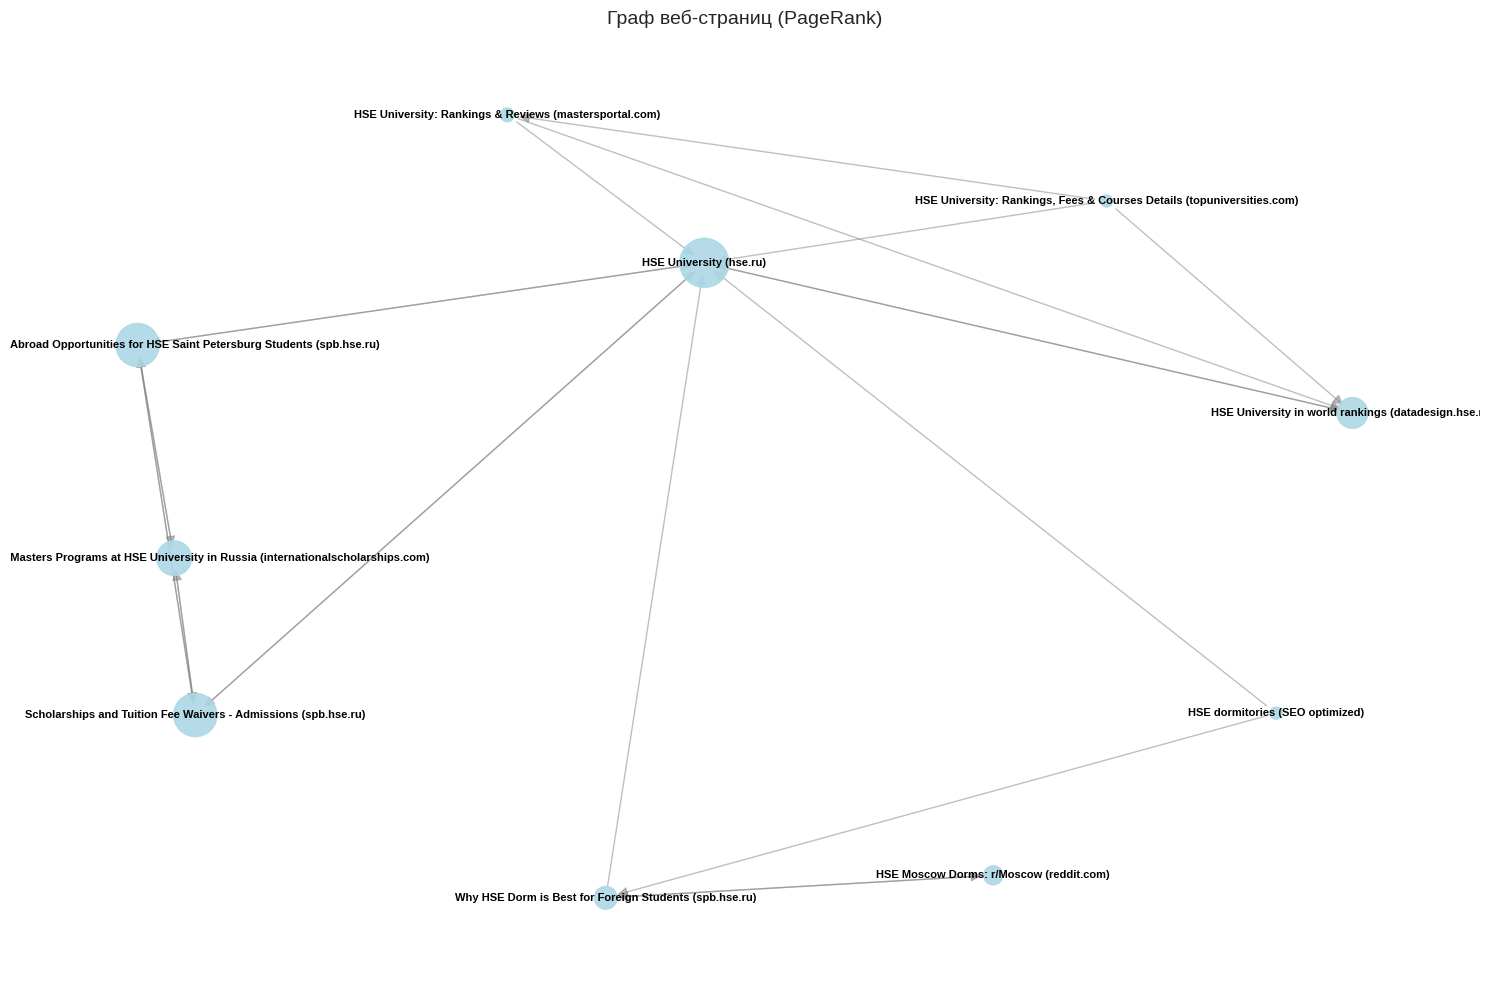


PageRank scores:
  HSE University (hse.ru)                            0.2496
  Scholarships and Tuition Fee Waivers - Admissions  0.1936
  Scholarships - Study Abroad Opportunities for HSE  0.1936
  Scholarships for Masters Programs at HSE Universit 0.1247
  HSE University in world rankings (datadesign.hse.r 0.0982
  Why HSE Dorm is Best for Foreign Students (spb.hse 0.0534
  HSE Moscow Dorms: r/Moscow (reddit.com)            0.0377
  HSE University: Rankings & Reviews (mastersportal. 0.0192
  HSE University: Rankings, Fees & Courses Details ( 0.0150
  HSE dormitories (SEO optimized)                    0.0150


In [20]:
G = nx.DiGraph()
for page_id, page in engine.pages.items():
    G.add_node(page_id, title=page['title'], pagerank=engine.pagerank[page_id])
    for link in page['outgoing_links']:
        if link in engine.pages:
            G.add_edge(page_id, link)

plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=2, seed=42)
node_sizes = [engine.pagerank[node] * 5000 for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=15, alpha=0.5)
labels = {node: G.nodes[node]['title'] for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
plt.title("Граф веб-страниц (PageRank)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nPageRank scores:")
for page_id, pr in sorted(engine.pagerank.items(), key=lambda x: x[1], reverse=True):
    print(f"  {engine.pages[page_id]['title'][:50]:50} {pr:.4f}")

"Центром" графа является узел самой авторитетной страницы - официального сайта Вышки, на него ссылается подавляющее большинство страниц из выборки. Остальные узлы расположены вокруг центрального, причем наиболее близки тематически связанные страницы (которые имеют внешние ссылки друг на друга). Следующие по величине (и PageRank score соответственно) узлы обозначают страницы о стипендиях. Самые маленькие и удаленные узлы - документы об общежитиях (в т.ч. SEO-оптимизированная страница) и о рейтингах (сторонних, неофициальных ресурсов).

### Бонус. Оценка качества (доп. 2 балла)

Для одного из запросов вручную определите **релевантные страницы** (ground truth). Вычислите для гибридной конфигурации:

- Precision@3
- Recall@3
- Average Precision
- NDCG@3 (с relevance scores: 2 — очень релевантна, 1 — частично, 0 — не релевантна)

In [50]:
query = "hse university rankings"

ground_truth = {
    "page1": 1,
    "page2": 2,
    "page3": 2,
    "page4": 2,
    "page5": 0,
    "page6": 0,
    "page7": 0,
    "page8": 0,
    "page9": 0,
    "page10": 0
}

top_k = 3
results = engine.search(query, weights={"bm25": 0.4, "tfidf": 0.4, "pagerank": 0.2}, top_k=top_k)

print("Search Results:")
for i, r in enumerate(results, 1):
    relevance = ground_truth.get(r['id'], 0)
    print(f"{i}. {r['title']} - {r['id']} | relevance: {relevance}")

# вычисляем precision@3 и recall@3
predicted_ids = [r['id'] for r in results]
relevant_retrieved = sum(1 for pid in predicted_ids if ground_truth.get(pid, 0) > 0)
total_relevant = sum(1 for rel in ground_truth.values() if rel > 0)

precision_at_3 = relevant_retrieved / top_k
recall_at_3 = relevant_retrieved / total_relevant if total_relevant > 0 else 0

print(f"\nPrecision@3: {precision_at_3:.3f}")
print(f"Recall@3: {recall_at_3:.3f}")

# вычисляем average precision
ap = 0
relevant_count = 0
for i, r in enumerate(results, 1):
    if ground_truth.get(r['id'], 0) > 0:
        relevant_count += 1
        ap += relevant_count / i
ap = ap / total_relevant if total_relevant > 0 else 0
print(f"Average Precision: {ap:.3f}")

# вычисляем NDCG@3 (Normalized Discounted Cumulative Gain)
dcg = 0
idcg = 0
relevances = [ground_truth.get(r['id'], 0) for r in results]
ideal_relevances = sorted([rel for rel in ground_truth.values()], reverse=True)[:top_k]
for i, rel in enumerate(relevances, 1):
    dcg += rel / log2(i + 1)
for i, rel in enumerate(ideal_relevances, 1):
    idcg += rel / log2(i + 1)
ndcg = dcg / idcg if idcg > 0 else 0
print(f"NDCG@3: {ndcg:.3f}")

Search Results:
1. HSE University: Rankings & Reviews (mastersportal.com) - page4 | relevance: 2
2. HSE University: Rankings, Fees & Courses Details (topuniversities.com) - page2 | relevance: 2
3. HSE University in world rankings (datadesign.hse.ru) - page3 | relevance: 2

Precision@3: 1.000
Recall@3: 0.750
Average Precision: 0.750
NDCG@3: 1.000


На "игрушечной" коллекции созданный SearchEngine показывает хорошие результаты: в выдачу попадают наиболее релевантные страницы. Метрика Recall@3=0.75 показывает, что 1 из 4 релевантных страниц не попала в top-3 (ведь мы искали только тройку самых релевантных).